In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point
import matplotlib.pyplot as plt
import networkx as nx
from pyproj import Transformer, CRS

In [2]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df = pd.read_csv(data_path, sep=';')

df.head()

,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp,next_cluster,cluster
0,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,89,1,2.940217,0.279338,5.909524,0.066667,0.000749,15.0,8
1,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,SM,89,1,2.940217,0.095890,5.909524,0.066667,0.000749,19.0,15
2,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,SM,89,1,2.940217,0.271233,5.909524,0.066667,0.000749,19.0,19
3,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,WM,89,1,2.940217,0.076712,5.909524,0.066667,0.000749,8.0,19
4,100431_1,BLSC,W,W1,2,M,ASY,Southern New England,Rhode Island,-70.839910,...,WM,89,1,2.940217,0.010959,5.909524,0.066667,0.000749,7.0,8


Numero totale di righe: 3246
Numero di righe con next_cluster valido: 2793
Righe dopo aver rimosso i self-loops: 1991
Self-loops rimossi: 802
Numero di cluster: 28

Numero di nodi nel grafo: 28
Numero di archi nel grafo: 270


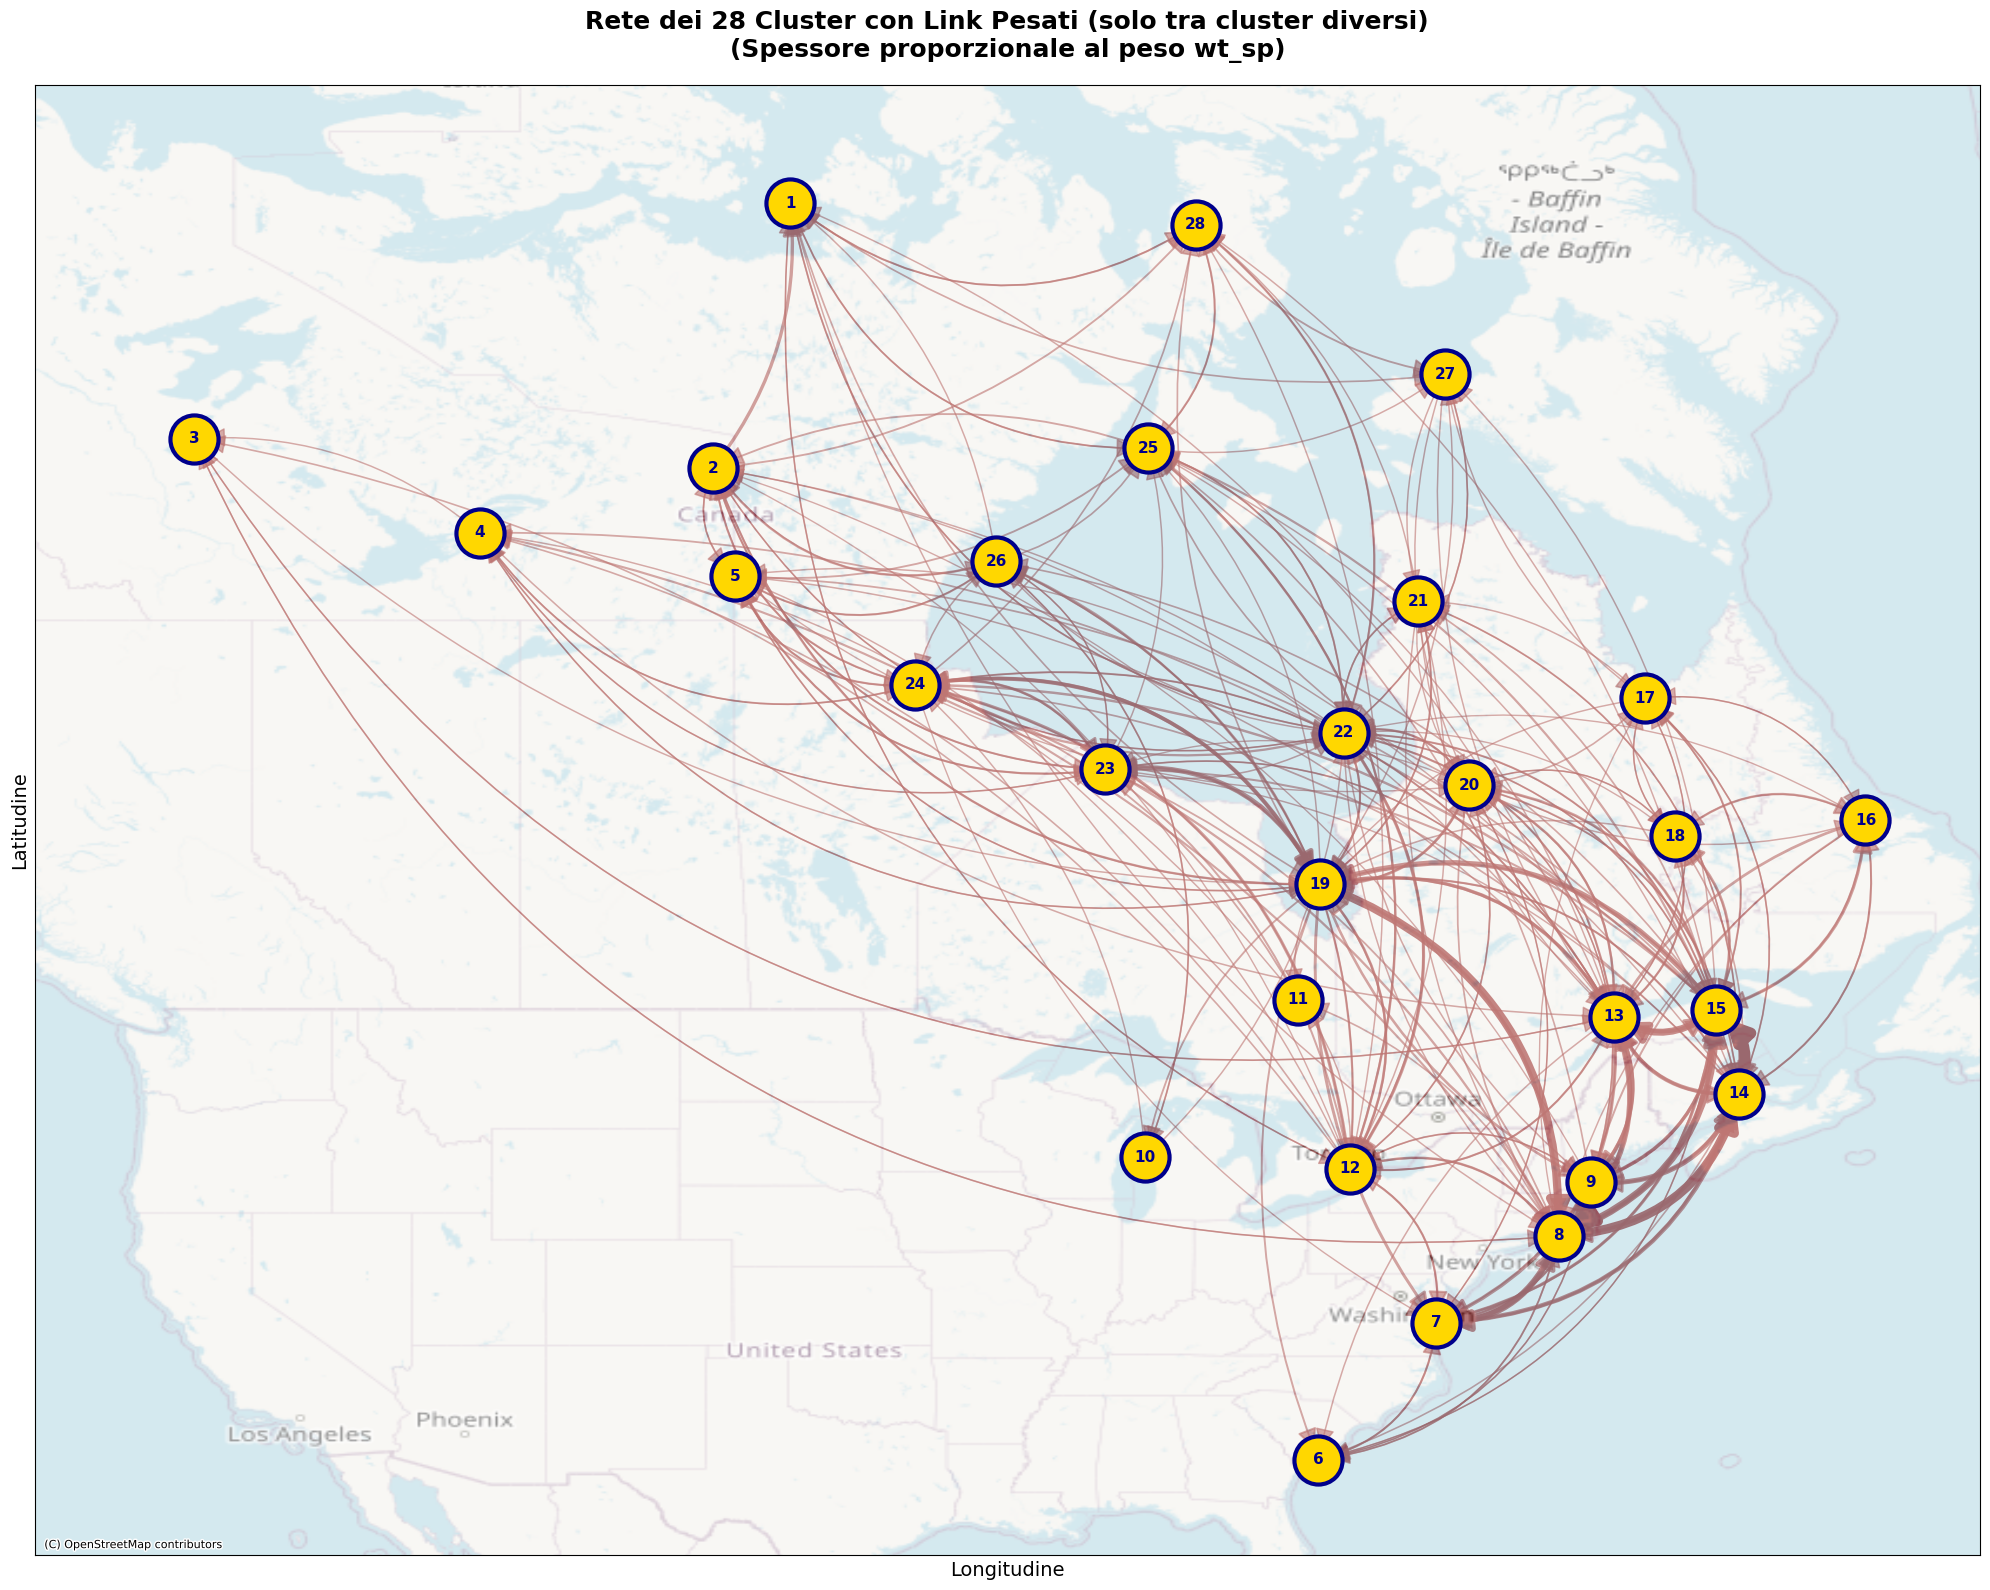

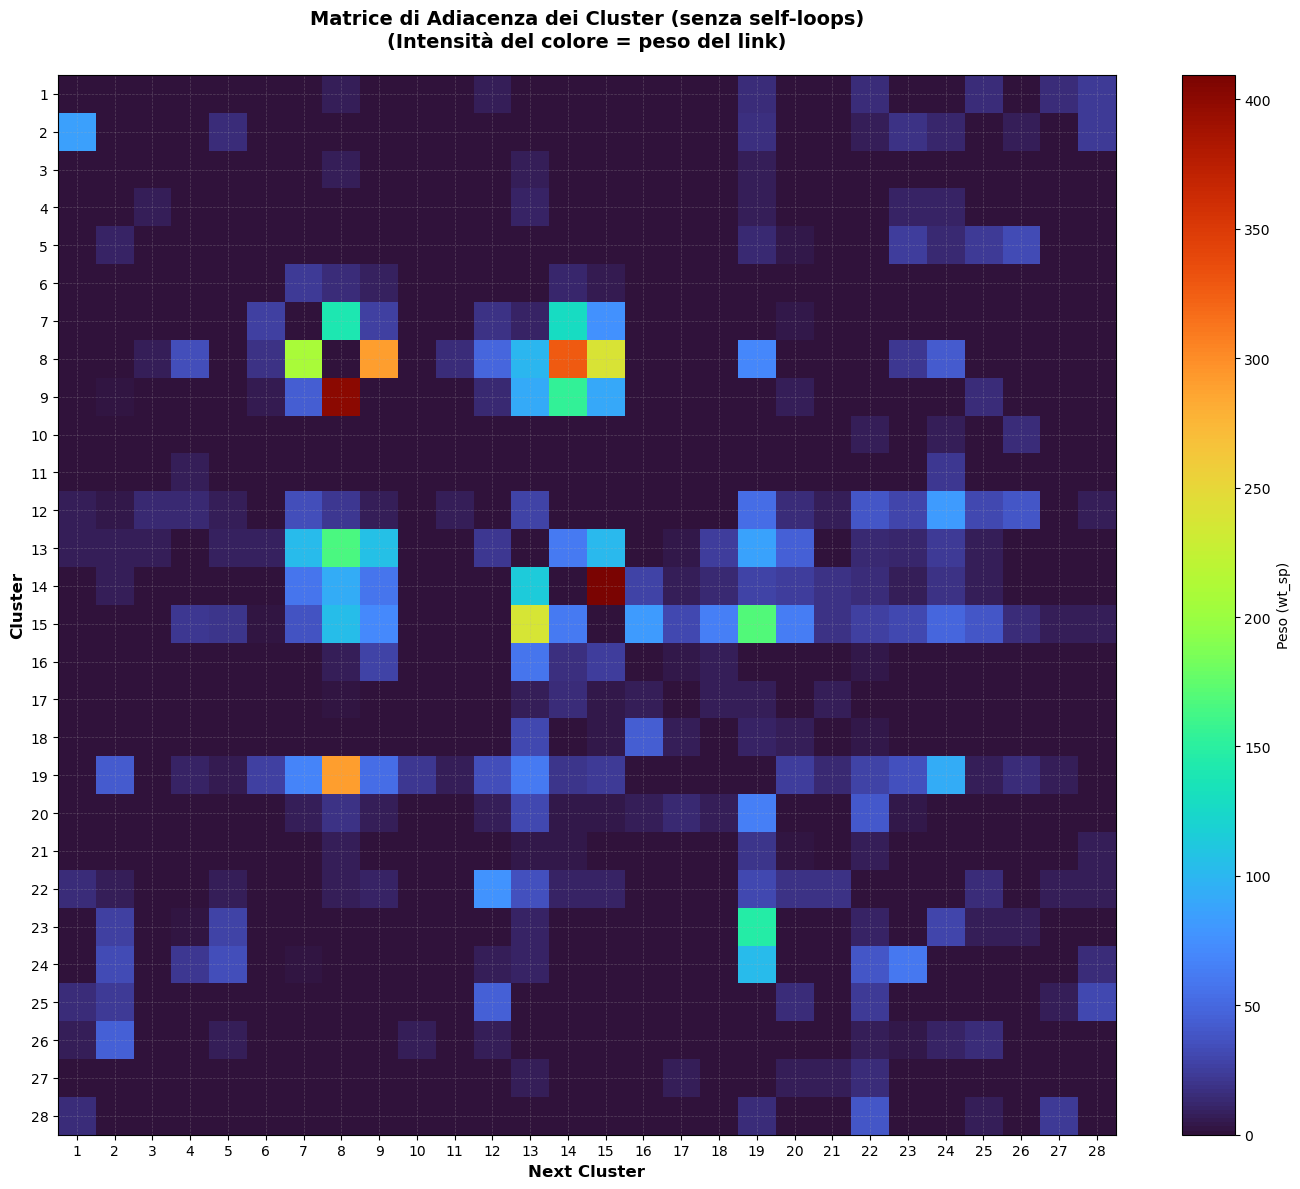

In [3]:
print(f"Numero totale di righe: {len(df)}")

#Filtro righe che hanno un next_cluster 
df_filtered = df[df['next_cluster'].notna()].copy()
df_filtered['next_cluster'] = df_filtered['next_cluster'].astype(int)
df_filtered['cluster'] = df_filtered['cluster'].astype(int)

#Rimozione self-loops (cluster == next_cluster)
df_links = df_filtered[df_filtered['cluster'] != df_filtered['next_cluster']].copy()

print(f"Numero di righe con next_cluster valido: {len(df_filtered)}")
print(f"Righe dopo aver rimosso i self-loops: {len(df_links)}")
print(f"Self-loops rimossi: {len(df_filtered) - len(df_links)}")
print(f"Numero di cluster: {df['cluster'].nunique()}")

#Aggregazione dei link: somma dei pesi wt_sp per ogni coppia (cluster, next_cluster)
edge_weights = df_links.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

G = nx.DiGraph()

all_clusters = set(range(1, 29))
G.add_nodes_from(all_clusters)

for _, row in edge_weights.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

print(f"\nNumero di nodi nel grafo: {G.number_of_nodes()}")
print(f"Numero di archi nel grafo: {G.number_of_edges()}")

weights = [G[u][v]['weight'] for u, v in G.edges()]
min_weight = min(weights)
max_weight = max(weights)

cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    x, y = transformer.transform(row['lon'], row['lat'])
    pos[row['cluster']] = (x, y)

for node in G.nodes():
    if node not in pos:
        x, y = transformer.transform(-80, 50)
        pos[node] = (x, y)

fig, ax = plt.subplots(figsize=(20, 16))

min_width = 1.0
max_width = 8
widths = [min_width + (max_width - min_width) * (G[u][v]['weight'] - min_weight) / (max_weight - min_weight) 
          for u, v in G.edges()]

alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight) / (max_weight - min_weight) 
          for u, v in G.edges()]

bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

#Archi con spessori proporzionali ai pesi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.2'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='darkred',
                           arrows=True,
                           arrowsize=30,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

nx.draw_networkx_nodes(G, pos, 
                       node_color='gold', 
                       node_size=1200,
                       edgecolors='darkblue',
                       linewidths=3,
                       ax=ax)

nx.draw_networkx_labels(G, pos, 
                        font_size=11, 
                        font_weight='bold',
                        font_color='darkblue',
                        ax=ax)


cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)

ax.set_title('Rete dei 28 Cluster con Link Pesati (solo tra cluster diversi)\n(Spessore proporzionale al peso wt_sp)', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitudine', fontsize=14)
ax.set_ylabel('Latitudine', fontsize=14)

plt.tight_layout()

#Matrice di adiacenza pesata
plt.figure(figsize=(14, 12))

adjacency_matrix = np.zeros((28, 28))
for _, row in edge_weights.iterrows():
    adjacency_matrix[int(row['source'])-1, int(row['target'])-1] = row['weight']

im = plt.imshow(adjacency_matrix, cmap='turbo', aspect='auto', vmin=0)
plt.colorbar(im, label='Peso (wt_sp)')

plt.xticks(range(28), range(1, 29))
plt.yticks(range(28), range(1, 29))
plt.xlabel('Next Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Cluster', fontsize=12, fontweight='bold')
plt.title('Matrice di Adiacenza dei Cluster (senza self-loops)\n(Intensità del colore = peso del link)', 
          fontsize=14, fontweight='bold', pad=20)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()


plt.show()

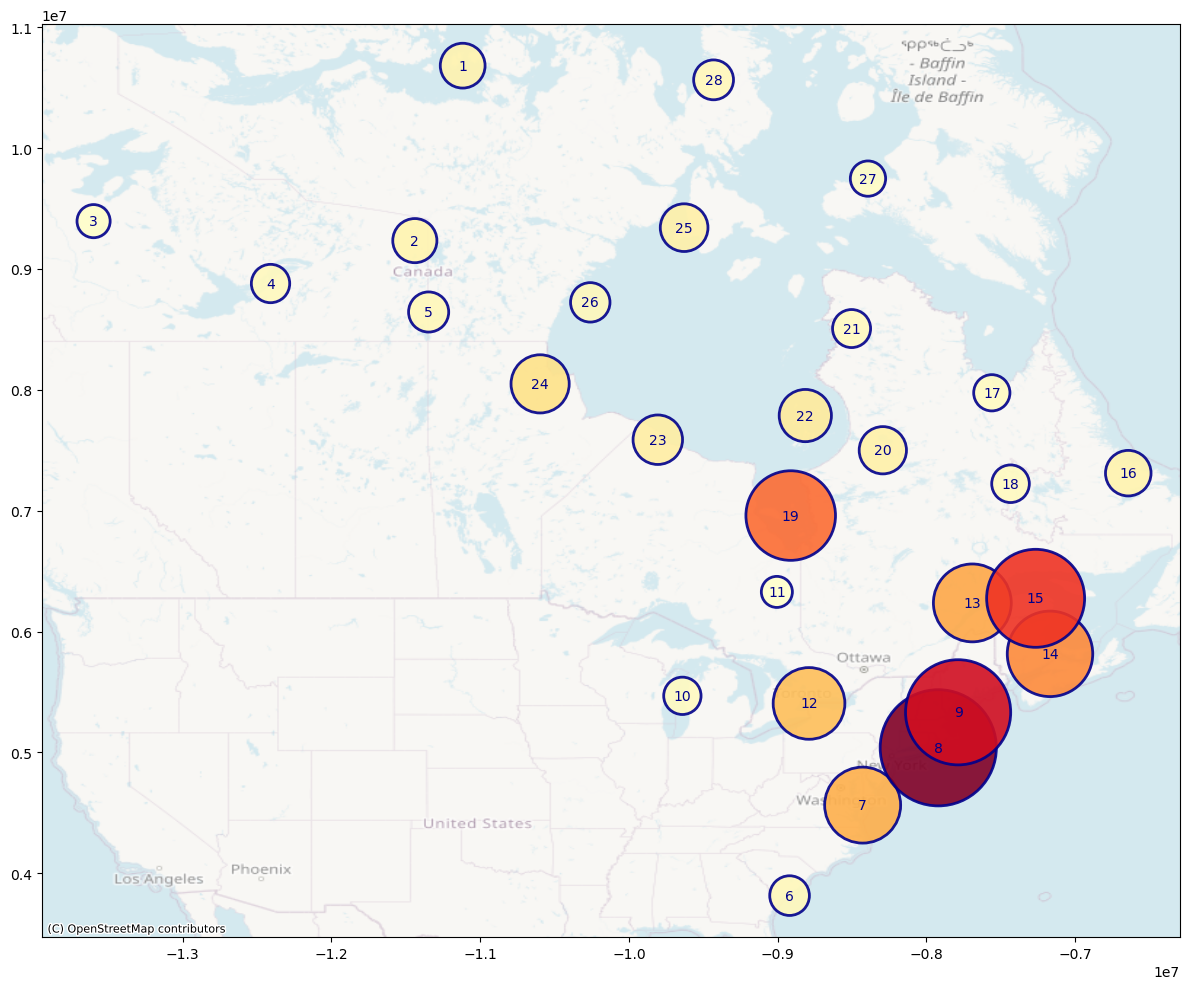

In [4]:
#Calcolo del peso totale per ogni cluster (somma di wt_sp)
cluster_weights = df.groupby('cluster')['wt_sp'].sum().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

positions_scatter = []
weights_scatter = []
labels_scatter = []

for _, row in cluster_data.iterrows():
    x, y = transformer.transform(row['lon'], row['lat'])
    positions_scatter.append((x, y))
    weights_scatter.append(row['total_weight'])
    labels_scatter.append(int(row['cluster']))

min_size = 500
max_size = 7000
min_weight_scatter = min(weights_scatter)
max_weight_scatter = max(weights_scatter)

node_sizes = [min_size + (max_size - min_size) * (w - min_weight_scatter) / (max_weight_scatter - min_weight_scatter) 
              for w in weights_scatter]

fig2, ax2 = plt.subplots(figsize=(12, 10))

x_coords_scatter = [p[0] for p in positions_scatter]
y_coords_scatter = [p[1] for p in positions_scatter]

#Nodi
scatter = ax2.scatter(x_coords_scatter, y_coords_scatter, 
                     s=node_sizes, 
                     c=weights_scatter,
                     cmap='YlOrRd',
                     alpha=0.9,
                     edgecolors='darkblue',
                     linewidths=2,
                     zorder=3)

for i, label in enumerate(labels_scatter):
    ax2.text(x_coords_scatter[i], y_coords_scatter[i], str(label),
            fontsize=10, fontweight='normal', 
            ha='center', va='center',
            color='darkblue',
            zorder=4)


cx.add_basemap(ax2, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

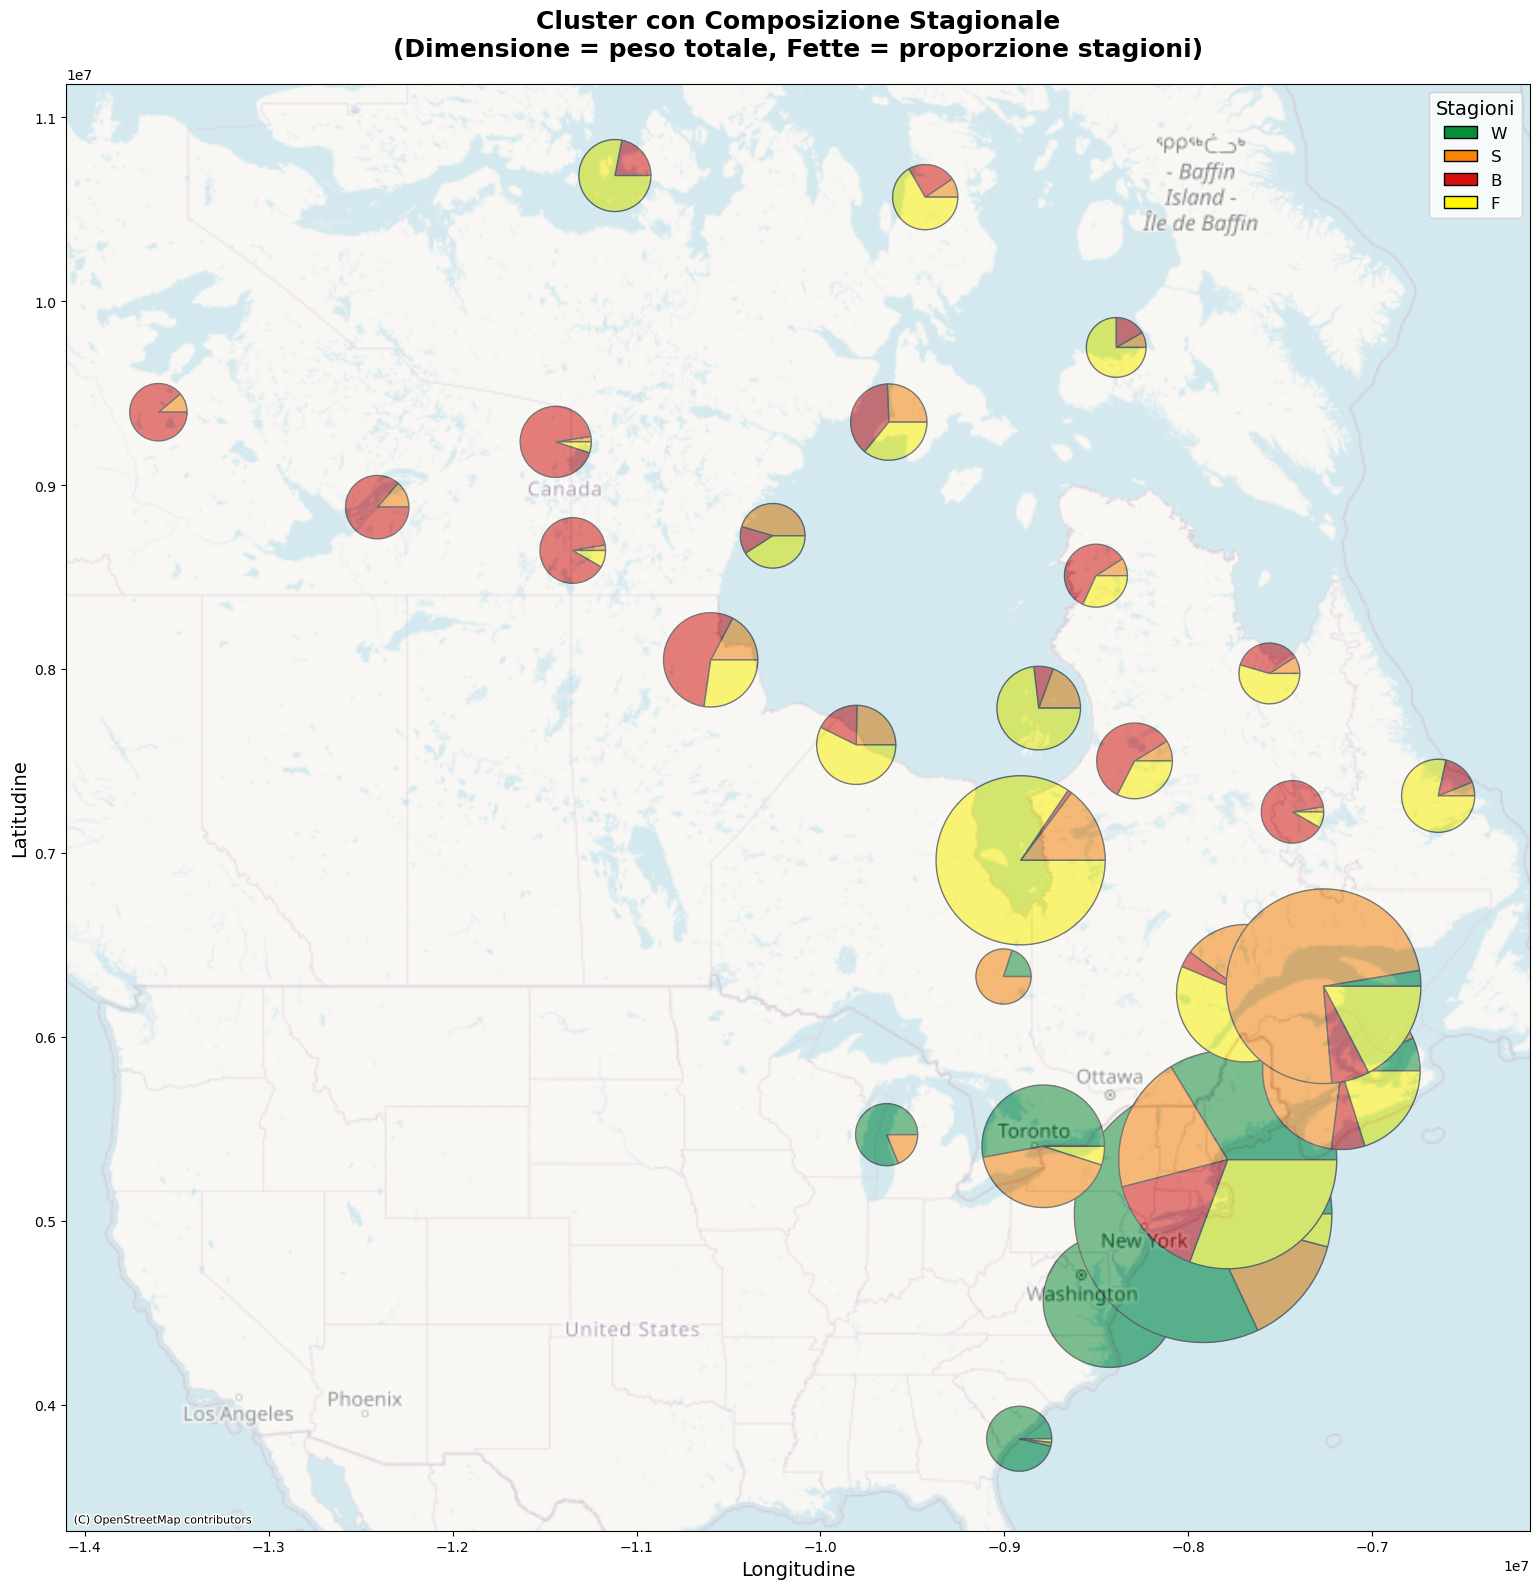

In [6]:

from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

season_counts = df.groupby(['cluster', 'season']).size().unstack(fill_value=0)

season_colors = {
    'W': "#078D38",  #Winter
    'S': "#F88305",  #Spring
    'B': "#D50E0E",  #Breeding
    'F': "#FFF700"   #Fall
}
season_order = ['W', 'S', 'B', 'F']
fig3, ax3 = plt.subplots(figsize=(20, 16))


for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    x, y = transformer.transform(row['lon'], row['lat'])
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            
            weight = row['total_weight']
            
            radius = 150000 + (700000 - 150000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='black', linewidth=1, alpha=1.0)
                ax3.add_patch(wedge)
                start_angle += angle
            
           


ax3.set_xlim(min(x_coords_scatter) - 500000, max(x_coords_scatter) + 500000)
ax3.set_ylim(min(y_coords_scatter) - 500000, max(y_coords_scatter) + 500000)
ax3.set_aspect('equal')


cx.add_basemap(ax3, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)


legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', label=s) 
                   for s in season_order]
ax3.legend(handles=legend_elements, title='Stagioni', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax3.set_title('Cluster con Composizione Stagionale\n(Dimensione = peso totale, Fette = proporzione stagioni)', 
             fontsize=18, fontweight='bold', pad=20)
ax3.set_xlabel('Longitudine', fontsize=14)
ax3.set_ylabel('Latitudine', fontsize=14)


plt.tight_layout()
plt.show()

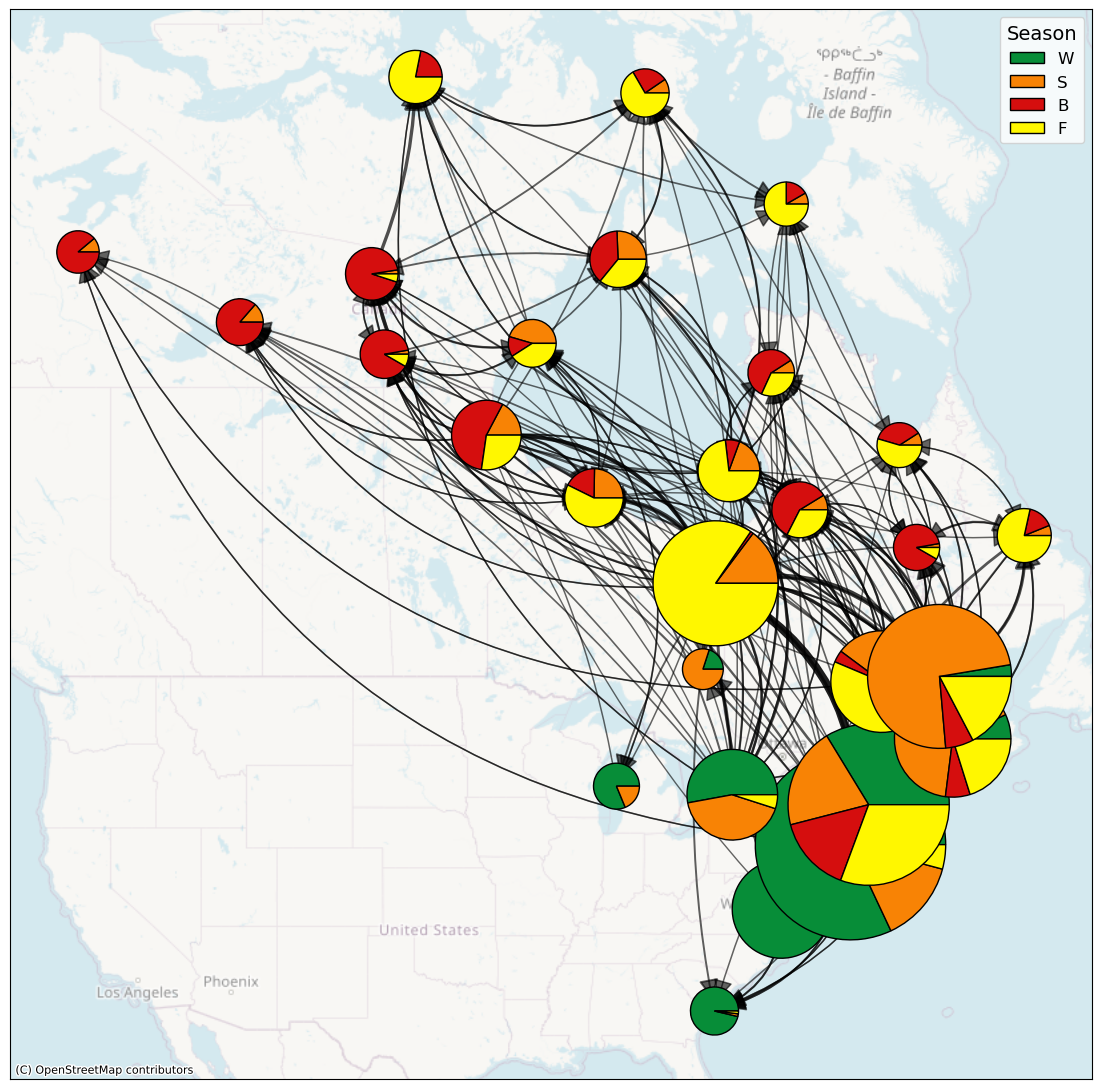

In [7]:
fig4, ax4 = plt.subplots(figsize=(13, 11))

bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='black',
                           arrows=True,
                           arrowsize=30,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax4)


for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    x, y = transformer.transform(row['lon'], row['lat'])
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            radius = 150000 + (700000 - 150000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='black', linewidth=1, alpha=1.0)
                ax4.add_patch(wedge)
                start_angle += angle
            


ax4.set_xlim(min(x_coords_scatter) - 500000, max(x_coords_scatter) + 500000)
ax4.set_ylim(min(y_coords_scatter) - 500000, max(y_coords_scatter) + 500000)
ax4.set_aspect('equal')

cx.add_basemap(ax4, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)

legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', label=s) 
                   for s in season_order]
ax4.legend(handles=legend_elements, title='Season', 
          loc='upper right', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()

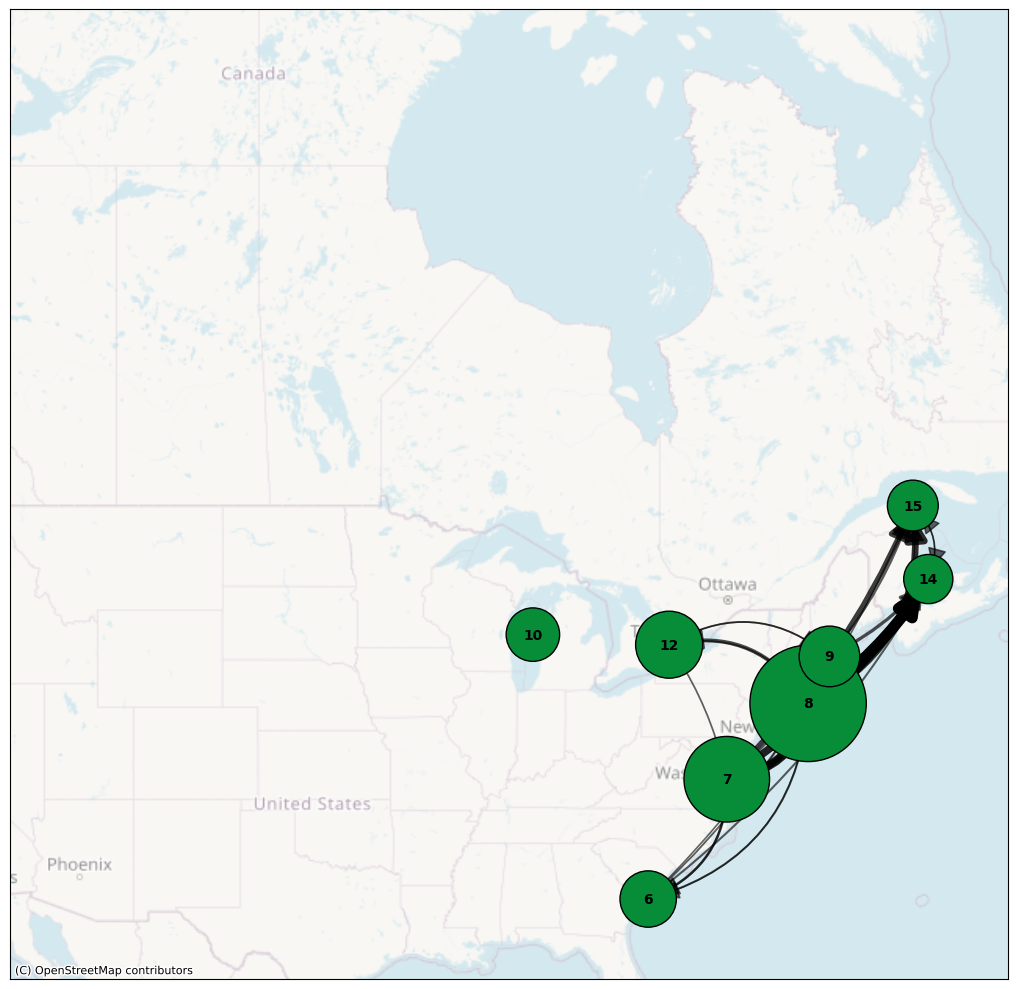

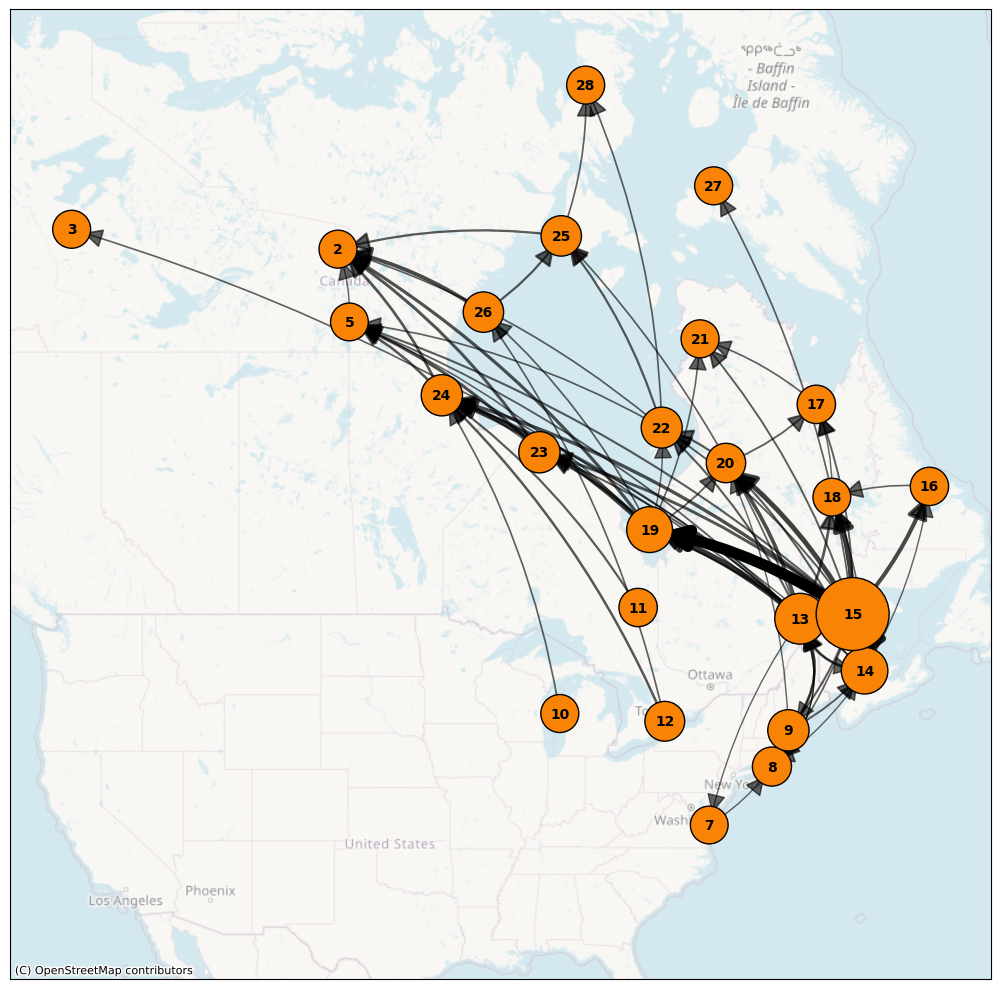

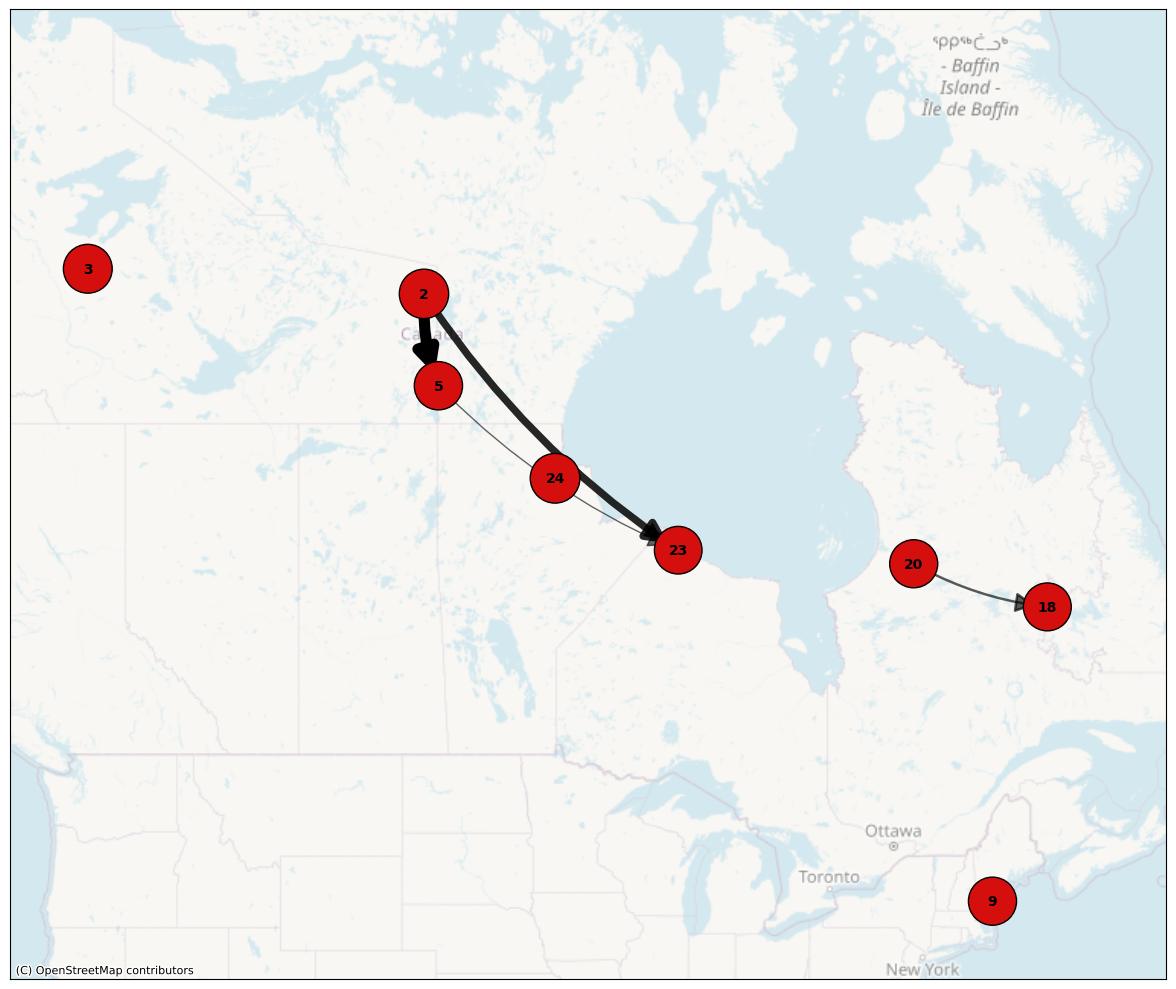

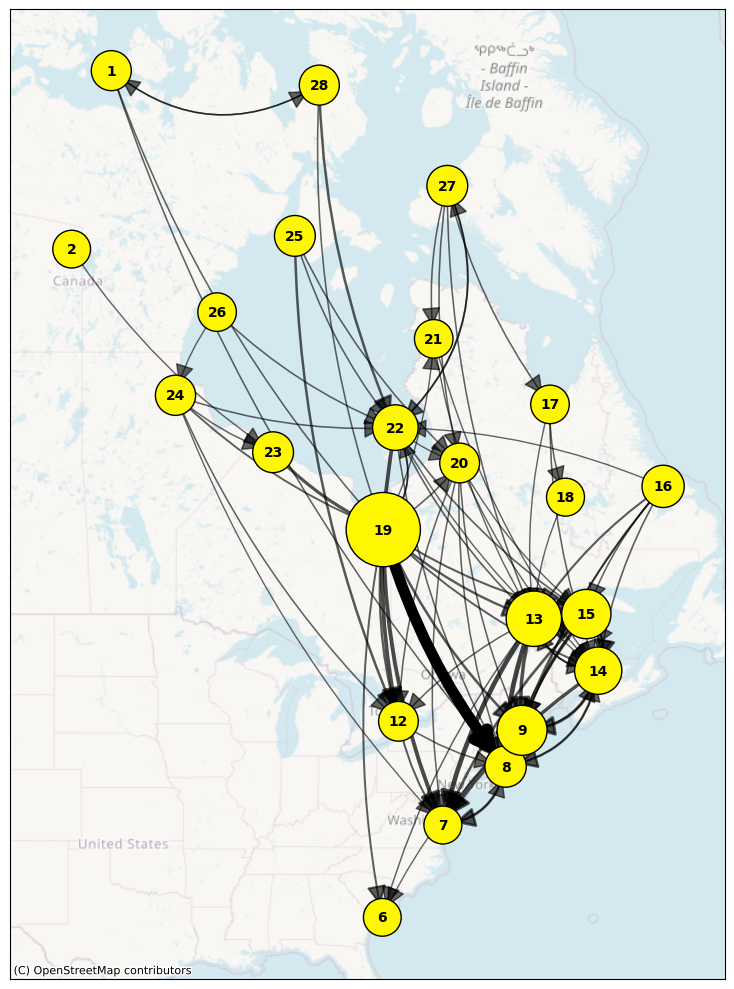

In [ ]:

from matplotlib.patches import Circle

seasons = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

all_season_weights = []
for season in seasons:
    df_s = df[(df['from_sea'] == season) & (df['to_sea'] == season)]
    if len(df_s) > 0:
        weights = df_s.groupby('cluster')['wt_sp'].sum()
        all_season_weights.extend(weights.values)

min_weight_global = min(all_season_weights)
max_weight_global = max(all_season_weights)


for season in seasons:
    
    df_season = df[(df['from_sea'] == season) & (df['to_sea'] == season)].copy()
    
    
    if len(df_season) == 0:
        continue
    
   
    df_season_filtered = df_season[df_season['next_cluster'].notna()].copy()
    df_season_filtered['next_cluster'] = df_season_filtered['next_cluster'].astype(int)
    df_season_filtered['cluster'] = df_season_filtered['cluster'].astype(int)
    
    
    df_season_links = df_season_filtered[df_season_filtered['cluster'] != df_season_filtered['next_cluster']].copy()
    
    
    
    if len(df_season_links) == 0:
        continue
    
    clusters_involved = set(df_season_links['cluster'].unique()) | set(df_season_links['next_cluster'].unique())
    
    
    edge_weights_season = df_season_links.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights_season.columns = ['source', 'target', 'weight']




    clusters_with_data = set(df_season['cluster'].unique())
    edge_weights_season = edge_weights_season[
        (edge_weights_season['source'].isin(clusters_with_data)) & 
        (edge_weights_season['target'].isin(clusters_with_data))
    ]

    

    if len(edge_weights_season) == 0:
        continue
    
    
    cluster_weights_season = df_season.groupby('cluster')['wt_sp'].sum().reset_index()
    cluster_weights_season.columns = ['cluster', 'total_weight']
    
   
    cluster_weights_season = cluster_weights_season[cluster_weights_season['cluster'].isin(clusters_involved)]
    
    cluster_data_season = cluster_coords.merge(cluster_weights_season, on='cluster')
    
    pos_season = {}
    for _, row in cluster_coords.iterrows():
        cluster_id = int(row['cluster'])
        if cluster_id in clusters_involved:
            x, y = transformer.transform(row['lon'], row['lat'])
            pos_season[cluster_id] = (x, y)
    
    
    G_season = nx.DiGraph()
    
    
    for _, row in edge_weights_season.iterrows():
        source = int(row['source'])
        target = int(row['target'])
        if source in pos_season and target in pos_season:
            G_season.add_edge(source, target, weight=row['weight'])
    
    if G_season.number_of_edges() == 0:
        print(f"Nessun link valido per la stagione {season}")
        continue
    
    
    weights_season = [G_season[u][v]['weight'] for u, v in G_season.edges()]
    min_weight_season = min(weights_season)
    max_weight_season = max(weights_season)
    
    
    widths_season = [1.0 + (8 - 1.0) * (G_season[u][v]['weight'] - min_weight_season) / (max_weight_season - min_weight_season) 
                     for u, v in G_season.edges()]
    
    alphas_season = [0.6 + 0.4 * (G_season[u][v]['weight'] - min_weight_season) / (max_weight_season - min_weight_season) 
                     for u, v in G_season.edges()]
    
    
    fig_season, ax_season = plt.subplots(figsize=(12, 10))
    
    
    bidirectional_edges_season = set()
    for u, v in G_season.edges():
        if G_season.has_edge(v, u):
            bidirectional_edges_season.add((min(u, v), max(u, v)))
    
    
    for (u, v), width, alpha in zip(G_season.edges(), widths_season, alphas_season):
        edge_pair = (min(u, v), max(u, v))
        
        if edge_pair in bidirectional_edges_season:
            rad = 0.35 if u < v else -0.35
            connectionstyle = f'arc3,rad={rad}'
        else:
            connectionstyle = 'arc3,rad=0.1'
        
        nx.draw_networkx_edges(G_season, pos_season, 
                               edgelist=[(u, v)], 
                               width=width,
                               alpha=alpha,
                               edge_color='black',
                               arrows=True,
                               arrowsize=30,
                               arrowstyle='-|>',
                               connectionstyle=connectionstyle,
                               ax=ax_season)
    
    
    if len(cluster_data_season) > 0:
        for _, row in cluster_data_season.iterrows():
            cluster_id = int(row['cluster'])
            x, y = transformer.transform(row['lon'], row['lat'])
            
            weight = row['total_weight']
            
            radius = 160000 + (700000 - 160000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            
            
            circle = Circle((x, y), radius, 
                           facecolor=season_colors[season], 
                           edgecolor='black', 
                           linewidth=1, 
                           alpha=1.0)
            ax_season.add_patch(circle)
            
            
            ax_season.text(x, y, str(cluster_id),
                          fontsize=10, fontweight='bold',
                          ha='center', va='center',
                          color='black',
                          zorder=5)
    
   
    x_coords_season = [pos_season[n][0] for n in pos_season]
    y_coords_season = [pos_season[n][1] for n in pos_season]
    ax_season.set_xlim(min(x_coords_season) - 500000, max(x_coords_season) + 500000)
    ax_season.set_ylim(min(y_coords_season) - 500000, max(y_coords_season) + 500000)
    ax_season.set_aspect('equal')
    
    cx.add_basemap(ax_season, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    
    plt.tight_layout()
    
    plt.show()
    
    